# Tutorial 2: Pandas
-----------------------------------------------
## Overview
NumPy is very fast at handling data. However, it is limited by allowing only ONE data type. Pandas adds the familiar data structure like a spreadsheet, with data organized in rows and columns with names. Why not just use Excel or Sheets, then? Because bioinformatics data sets, such as RNAseq results, are so large and you may need to do complex calculations on the data. Python tools are much faster, more powerful and more flexible than pre-packaged spreadsheet tools. Also, the data is typically not printed to the screen in a GUI interface so the processing speed is faster. If you process in the cloud, you can see substantial increases in speed of analysis.

### Learning Objectives

After this tutorial, you will be able to:
- Define "dataframe"
- Create a Pandas dataframe from scratch or from imported data
- Work with column and rows
- Sort, organize, query, and manipulate the Pandas dataframe
- Visualize pandas dataframes with simple tools
    
### Prerequisites

- Introductory Python
- NumPy (tutorial 2)

### Getting Started
* One way to get introduced to Pandas is provided by pydata: [10 minutes to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html) or their [getting started tutorials](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html)
* Watch the brief Lecture
* As with NumPy, the custom is to import pandas with the alias of pd to save your typing time.

In [6]:
#Run this code box to install required packages
#%pip install jupyterquiz
import pandas as pd
from jupyterquiz import display_quiz
import os
print("All needed tools imported")

All needed tools imported


## Why Pandas?​

The scripting in Python is good till now, but what about data organization or handling columns of tabular data with different types? ​

Pandas focuses on **data management** which can be combined with **analytics tools**​

The core data type is a DataFrame. A DataFrame organizes data into rows and columns, making it easy to access, filter, and process.
![Structure of a Dataframe](pandasDF.png)

You can think of it like an Excel spreadsheet or (more appropriately) like a database table​
  - Tabular​
  - Same data type within Column, but the data type can vary by column​


## Why use DataFrames in Bioinformatics?

In bioinformatics, data often comes in tabular formats, such as gene expression matrices, genomic variant tables, or protein interaction datasets. A Pandas DataFrame provides:

1. Ease of Handling Tabular Data:
    - Rows can represent biological samples, sequences, or variants.
    - Columns can represent genes, features, or metadata.
    - Unlike Excel, Pandas does not attempt to display all the values all the time, so it is less demanding on computer memory-- especially for the large datasets common to bioinformatics

2. Data Analysis: Perform operations like filtering, grouping, and summarizing efficiently.
    - Example: Find the top 10 most expressed genes in RNA-Seq data.

3. Integration: Read/write to biological data formats like CSV, Excel, or SQL.
    - Example: Import genomic data from a CSV file and perform preprocessing.

4. Visualization: Easily integrate with visualization libraries like Matplotlib
    - Example: Plot expression levels of genes across conditions.
    - Since Matplotlib can produce HIGH resolution images, this is a helpful tool for producing publication-ready figures

### Creating Data Frames

A Pandas dataframe can be constructed in many ways. (see [pandas documentation](https://pandas.pydata.org/docs/user_guide/dsintro.html#dataframe) for more ways). Each column is called a **Series** and has it's own functions in Pandas [see more]
We can create a dataframe by passing in a dictionary of equal length lists​

  * The dictionary keys will be column names​

We can also create dataframes from file loads and queries

Here, you see how it is made with a dictionary as the data that you might assemble yourself. 

In [10]:
# Make Dataframe
import pandas as pd 
import numpy as np

data = {'id': list(range(1,11)),
'yr': list(range(2020,2025))*2,
'count': np.random.randint(10,40,10)}
frame = pd.DataFrame(data)

frame


,id,yr,count
0,1,2020,13
1,2,2021,35
2,3,2022,17
3,4,2023,22
4,5,2024,24
5,6,2020,18
6,7,2021,30
7,8,2022,13
8,9,2023,15
9,10,2024,29


### Importing structured data sets (e.g. CSV)

Probably the most common way to create a Pandas dataframe is to **import a CSV** for further analysis. ​

You can also import excel, JSON, and the clipboard. [All the data types and import methods](http://pandas.pydata.org/pandas-docs/stable/io.html)

Try the next box to import a portion of a large cancer dataset. 

In [12]:
import os
cancer = pd.read_csv("."+os.sep + "Datasets" + os.sep + "cancer.csv")
len(cancer)

301

### Another sample dataset: states
Before we tackle bioinformatics datasets, it is customary to work with a toy dataset for which we have some intuition. A dataframe of information about the US states will allow you to learn and practice some Pandas skills.

Can you import the states.csv file from the same folder as cancer? Assign that to the variable states. The code is commented out in the next section, in case you aren't able.

In [14]:
# Import the states.csv file as a pandas dataframe as states



As soon as we import data, step one should be to check the data import​. Look at the first 3 rows. Showing 5 rows is default, or you can specify with df.head(n=x)


In [16]:
states = pd.read_csv("." + os.sep + "Datasets" + os.sep + "states.csv")
# View
states.head(n=3)
#states.tail()


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad
0,Alabama,3615,3624,2.1,69.05,15.1,41.3
1,Alaska,365,6315,1.5,69.31,11.3,66.7
2,Arizona,2212,4530,1.8,70.55,7.8,58.1


## Pandas tools

### Summary Statistics
Are the number of rows as expected? What about the column names? General range of continuous variables? It's easy to asses​s (much more so than with a spreadsheet!!)

A Pandas dataframe has a method (df.describe()) that can easily summarize each column. *The summary information is itself a dataframe*  To get summary statistics on a single column, just specify that with the name in quotes as shown.

Can you obtain these same statistics for the cancer dataset? Note: these values could be meaningful for normalizing gene expression (later tasks)

In [19]:
states.describe()
#states["Murder"].describe()


,Population,Income,Illiteracy,Life Exp,Murder,HS Grad
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,4246.420000,4435.800000,1.170000,70.878600,7.37800,53.108000
std,4464.491433,614.469939,0.609533,1.342394,3.69154,8.076998
min,365.000000,3098.000000,0.500000,67.960000,1.40000,37.800000
25%,1079.500000,3992.750000,0.625000,70.117500,4.35000,48.050000
50%,2838.500000,4519.000000,0.950000,70.675000,6.85000,53.250000
75%,4968.500000,4813.500000,1.575000,71.892500,10.67500,59.150000
max,21198.000000,6315.000000,2.800000,73.600000,15.10000,67.300000


### Rows and Columns 

We also may want to look at just the list of row identifiers (names), or column names. These are stored as attributes of the Pandas dataframe, so we can access the array directly as df.columns or df.index *Though unless reset, the rownames are just a range of numbers*  

**What are the columns in the cancer dataset?**)​


In [21]:
# List Columns
states.columns
# List the row identifiers (though it is just numbers, so python describes it succinctly!
#states.index

#you can change the indices
#states.index=states["State"]
#states.index
#states.head()

Index(['State', 'Population', 'Income', 'Illiteracy', 'Life Exp', 'Murder',
       'HS Grad'],
      dtype='object')

As with np arrays, you can reference different dimensions.  **df.loc** attribute accesses a group of rows and columns by label(s) or a boolean array in the given DataFrame:
df.loc [:, range] selects a set of columns
df.loc[range,:] selects a set of rows​

Thus, you can subset some rows and some columns based on columns. (next, we'll make a subset based on characteristics like size of the population.)

The code is set up for the states dataframe. Try repeating for columns and/or rows in the cancer dataframe.

In [23]:
#Take a slice of columns

states.loc[0:8,'Population':'Illiteracy']
#states.loc['Population':'Illiteracy']
#states.loc[3:7,:]
#states[3:7]


,Population,Income,Illiteracy
0,3615,3624,2.1
1,365,6315,1.5
2,2212,4530,1.8
3,2110,3378,1.9
4,21198,5114,1.1
5,2541,4884,0.7
6,3100,5348,1.1
7,579,4809,0.9
8,8277,4815,1.3


### Indexes

We can select portions of the data frame by indexes (rows and columns) in a variety of ways

In [25]:
# Indexing
# Select Column. Head or the values are used to limit the display
#states['State'].head()
states.State[0:6]

0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
5      Colorado
Name: State, dtype: object

In [67]:
# Or select more than one column
states[['Income', 'State']].head()
 

,Income,State
0,3624,Alabama
1,6315,Alaska
2,4530,Arizona
3,3378,Arkansas
4,5114,California


In [ ]:
# Select Row (labels, index)
states[0:2]


We can also index with **boolean​s**. We've shown how to select for states. 

Can you select for genes with a minimal level of expression across all the samples? across some of the samples? 

In [ ]:
# select by boolean characteristics

states[states.Murder <= 2.7]


### Test your Knowledge
> 1. Efficiently determine how many states have a life expectancy between 70 and 71
> 2. What is the average HS Graduate percentage for these states?

In [ ]:
#Run this code box for a quiz
from jupyterquiz import display_quiz
import os
lenqz= "." + os.sep + "PythonQuizQuestions" + os.sep + "pd_boolean_lengthQz.json"

display_quiz(lenqz)

In [ ]:
#Answers
x=states.loc[(states['Life Exp']>71) & (states['Life Exp']>70)]
len(x)
#x['HS Grad'].mean()


In [ ]:
# select by integer location
states.iloc[0:5,0:3] 
 
# select columns by label, inclusive 
#states.loc[0:8,"Population":"Murder"]
# end inclusive



### Working with Text 

Strings in Pandas are roughly the same as strings in Python​

We simply operate on series rather than a single object​

Pandas provides many of the same methods, such as **len()**, **lower()**, **upper()**, **split()** and others you have seen before​

Pandas methods also usually ignore missing NaN values​

In [ ]:
s = pd.Series(['Tom', 'William Rick', 'John', 'Alber@t'
               , np.nan, '1234','SteveSmith'])

print(s)
print(s.str.len())
#print(s.str.lower())
#print(s.str.upper())

## Practice your Pandas skills

<p style="background:green;color:white;font-family:arial">
    Time to practice what you've just learned. You will:</p>

1. Assemble the qPCR data into a dataframe
2. Use indexing to access all Ct values for Sample1.
3. Generate summary statistics for the Ct_Value column.
4. Answer questions about the data by coding queries on the DataFrame.


Here is your data and metadata (you'll have to edit slightly & use Pandas coding to make it into a dataframe.)
- Target: \['GeneA', 'GeneB', 'GeneC', 'GeneA', 'GeneB', 'GeneC'],
- Sample: \['Sample1', 'Sample1', 'Sample1', 'Sample2', 'Sample2', 'Sample2'],
- Ct_Value: \[25.4, 28.7, 30.1, 26.2, 29.5, 31.0]

<p style="background:green;color:white;font-family:arial">Use the next box for practice, then run the subsequent quiz python box. Solution options follow the quiz</p>

In [ ]:
import pandas as pd

# Create a qPCR DataFrame

#Access the Ct values and/or obtain summary statistics

In [ ]:
import os
from jupyterquiz import display_quiz
indqz = "." + os.sep + "PythonQuizQuestions" + os.sep + "indqz.json"
display_quiz(indqz)

How to solve the Knowledge Test problems

<table>
    <thead>
        <tr>
            <th>Task</th>
            <th>Required Coding</th>
            <th>Answer</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Mean Ct value</td>
            <td><code>df.describe()</code> or <code>df['Ct_Value'].mean()</code></td>
            <td><strong>28.48</strong></td>
        </tr>
        <tr>
            <td>All Ct for Sample1</td>
            <td><code>df.loc[df['Sample'] == 'Sample1', 'Ct_Value']</code></td>
            <td>Outputs all Sample1 Ct values</td>
        </tr>
        <tr>
            <td>Minimum Ct for GeneA</td>
            <td><code>df.loc[df['Target'] == 'GeneA', 'Ct_Value'].min()</code></td>
            <td><strong>25.4</strong></td>
        </tr>
    </tbody>
</table>


## Manipulating Dataframes

### Adding/Deleting columns

We can add columns by naming a new column, then assigning a set of values​. If the added column doesn't have enough values, Pandas will automatically add NaN

Use the **del** keyword to delete a column​

<p style="background:green;color:white;font-family:arial"> Try this: You might have noticed that the first two columns of the cancer dataset are basically the same. Drop one of them & check the head to show you were successful.</p>

In [ ]:
# Add Column
states["NewCol"] = 4
 
# Delete Column
#del states["NewCol"]
states.head()

### Adding/deleting ROWS
​
The syntax is slightly more complex to add a row to a Pandas dataframe. 

You can make a new row, then **concat**, that is to concatenate the data. This row should be a single dictionary for one row, or multiple dictionaries to add multiple rows. Since it's a dictionary, you don't have to put the data in the 'correct' order of the existing dataframe. 

new_row= pd.DataFrame(\[{key:value, key1:value1, key2:value2}]

If you do not give a value for each of the columns, then Pandas will use NaN

Then, add that row of new data by concatenation. 
df = pd.concat(\[df, new_rows], ignore_index=True)

**To delete**, and to directly replace the dataframe using the inplace tag:

df.drop(index=\[Rowindex1, Rowindex2], inplace=True)

If you just drop one row, use index=#

In [ ]:
# Add one or more Rows by Concatenation

new_states = pd.DataFrame([{'State':'Puerto Rico', 'Murder':'17.2', 'Population':'3242'},{'State':'US VI', 'Population':'0.41','Murder':'40', 'HS Grad':'78'}])
states = pd.concat([states, new_states], ignore_index=True)

states.tail()

Now, remove Puerto Rico row, with df.drop, using its index & check the tail

In [ ]:
states.drop(index=50, inplace=True)
states.tail()

### Reindexing After Subsetting
Did you notice that while Pandas automatically adds the correct row index when concatenating, it does NOT automatically renumber or 'reindex'? 

You can use that to your advantage (remembering that US VI will always be index 51) or we can reindex:

**df.reset_index(drop=True, inplace=True)**


In [ ]:
# Reindex
states.reset_index(drop=True, inplace=True)  # you are dropping the column index which Pandas creates to "remember" the original index

states.tail()

### Merge

It might be useful to merge two dataframes together.  You need to picture them & ask yourself how they should be arranged- which of the 2 on the left & which on the right. *If it is just more ROWS with the same column names, that is accomplished as if you are "adding rows" as done above with df.concat* 

To merge them together, we can use the **pd.merge()** function & specify "where" each one goes. See the syntax below. Pandas uses information in your 2 dataframes to sync them (here, we specify that the STATE column is by what they are organized.

pd.merge(left, right, how='inner', on=None, left_on=None, right_on=None)
see [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) for explanations:erge key).


*The code below adds these two new columns to the right side of the sta and organizes based on statetes dataframe, but you should try adding to the left.*

In [ ]:
import os
# Import Dataframe
#states = pd.read_csv("." + os.sep + "Datasets" + "states.csv") # if you'd like a clean copy without USVI
states2 = pd.read_csv("." + os.sep + "Datasets" + os.sep + "states_extra.csv")
states2.head()

# Merge these together
#states_merge=pd.merge(states,states2,how="left", left_on="State", right_on="State")
#states_merge.tail()

-----------------------------------------------------------------------------------
## Data wrangling

A large challenge when working with real biological datasets is data "cleaning." This removes values or samples with errors (negative read counts, participants over age 110) or missing data (NaN) that could skew downstream analysis. This process must be carried out systematically and carefully. The normal workflow for this is beyond this introductory module. Please look at _____ for a full treatment.

### Dealing with Missing Values 

Pandas uses NaN to cover missing values​. You saw that when we added rows that did not give all the key:value pairs for every column.

This may occur for many reasons in bioinformatics:
1. A log2 fold-change might be NaN if the raw counts for a gene are zero in both conditions
2. In multiple sequence alignments (MSAs), some positions may lack data for certain sequences due to indels or incomplete sequence coverage. After processing such data into a DataFrame, these gaps may appear as NaN.
3. Combining datasets with mismatched identifiers or incomplete overlap of genes, samples, or annotations can introduce NaN values. For instance, merging a gene annotation file with an expression matrix may leave gaps for genes without annotations.
4. RNA-seq data may lack expression levels for some genes in certain samples due to low expression or poor sequencing depth.

You can drop a row (or col) that has missing data with **df.dropna(inplace=True)**    

You can fill missing values in with **df.fillna(#, inplace=True)**

- Why? for example for count data (e.g., RNA-seq), NaN might mean **no reads** were mapped, so replacing with *0* makes sense.

This will depend on your **knowledge** of the system and what NaN means or does not implyfor your particular dataset.

We will use a new function: mask(): Replace values where the condition is True.

<div class="alert alert-block alert-info"> <b>Tip:</b> In the following code, you'll need to remove various # to see the different results. </a>. </div>


In [ ]:
import numpy as np
import pandas as pd

# Creating a dataset with missing Data
states_miss  = states.copy() #so we can work with a separate copy, though states may incude USVI and/or PR

# Set all Population values below 1000 to missing (NaN)
states_miss['Population'] = states_miss['Population'].mask(states_miss['Population'] < 1000, np.nan)

# Now, drop missing data
#states_miss.dropna(inplace=True)                       #drops any row that has NaN 

#Or, replace them with zeros
#states_miss.fillna(0, inplace=True)


#to drop the column with NaN in it
#states_miss.dropna(axis=1, inplace=True)               # The only column with NaN is Population, which will be dropped from the states_miss dataframe
#states_miss.head()

#or, to change <1000 to "low" rather than NaN
#states_miss['Population'] = states_miss['Population'].mask(states_miss['Population'] < 1000, "low")

states_miss.loc[0:10,["State","Population"]]


We use **.isnull()** and **.notnull()** to check for missing values, with a resulting dataframe of True and False values​


In [ ]:
# isnull
states_miss.isnull().head()
#states_miss.notnull()


### Removing Duplicates

You've already seen how to remove NaN. It is also straightforward to remove duplicated data.

Duplicates in a Pandas DataFrame can be problematic for several reasons, depending on the context of your analysis or data manipulation.

It might mean
1. Data Integrity Issues
2. Increased Storage and Processing
3. Impact on Data Validation
4. Issues with Data Joins or Merges
5. Reduced Data Quality
6. Challenges in Machine Learning

Fortunately, Pandas has a simple way to manage these: 

- df.duplicated(): <u>Identifies</u> duplicate rows.
- df.drop_duplicates(): <u>Removes</u> duplicate rows.</u>
- df.duplicated(subset=\[...]): Checks for duplicates in <u>specific columns</u> only.

In [ ]:
# Make a dataframe with a duplicate row
#states = pd.read_csv("." + os.sep +"Datasets" + os.sep + "states.csv") # if you'd like a clean copy without USVI

states_dup = pd.concat([states, states.iloc[[1]]], ignore_index=True)

states_dup.tail()
#Then, remove the duplicates
#states_dup.duplicated().tail()  # Shows the boolean answer to 'is this a duplicate of another row?'

#states_dup.drop_duplicates().tail()

## Running functions on dataframes

Remembr that an advantage of using Pandas dataframes can streamline operations because they are built on top of NumPy, leveraging its efficient array processing capabilities, and they incorporate metadata (row/column labels, data types) that allow automatic alignment, indexing, and optimized handling of structured tabular data.

Functions can operate in two basic ways on a dataframe. 

- Data Reduction: Functions which reduce a list of inputs to 1 output (e.g., the results in the 'describe' function like mean and max).
     - These, by default, operate on the **column** ​
- "Element-wise": Functions which return one output result for each input operate on the dataframe element-by-element.
     -  df.applymap(lambda x: x\**2)    *to divide ALL values in df by 2*
     -  specify a column df\[column].apply(lambda x: x+2) *to add 2 to specific columns*
     -  round elements with df.round(2)​
 
We'll recall our first dataframe above (called frame) which has only integers to demonstrate a few functions on the whole dataframe

Note: lambda is a way to skip defining a function when we just need to do something function-like quickly

The subsequent boxes illustrate mean

In [ ]:
# Functions on DataFrames
frame.mean()
#cancer["2"].mean()
#result=states["Population"].apply(lambda x: x/1000)

#result.mean()

In [ ]:
# More Functions on DataFrames
 
# Returning More than One Value
states_copy = states.copy()
states_copy[["Population", "Illiteracy"]]=states_copy[["Population", "Illiteracy"]].diff()
states_copy.head()         #since there was nothing to subtract the first row of population & illiteracy frome, theose 

Doing an element-wise operation is the same as our original notion of vectorization​

Note in the sample here we are combining a table-wise and element-wise operation as a comparison​

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(5,3),columns=['col1','col2','col3'])
print(df.apply(np.mean))    # old mean
print(df.applymap(lambda x:x*100)) # modify elements
print(df.applymap(lambda x:x*100).apply(np.mean)) # new mean

### Sorting a DF 

We use **.sort_values(by='A')** to sort a data frame by the values in column A (where A could be any column name. The default is to sort from low to high, but you can choose descending with ascending=False

We can sort by more than one column(s), with ascending=\[forFirstColumn?,forTheSecond?]​

*we use .head() here only to limit the display size*

In [ ]:
# Sorting
states.sort_values(by='Population').head()
#states.sort_values(by="Population", ascending=False).head()

# Multiple sorts
#states.sort_values(by=["Illiteracy","Population"]).head()
#states.sort_values(by=["Illiteracy","Population"], ascending=[True,False]).head()

### Iterating over a series

Iterating over a series (1d) object is similar to an array or tuple​

Iterating over a dataframe or panel is a little trickier​

The iteration for them provides a dictionary object which has the columns/values of rows/values​

  - Use items() for column-wise​

  - Use iterrows() for row-wise​
  
The **iteritems()** method produces key, value pairs with the column name and the column values as a series​

In [ ]:
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})

for key, value in df.items():
    print(key,"   ", value)

#for key, value in df.iterrows():
#    print(key,"   ", value)

### Unique Values

We can use the .unique() function of Series to Get unique values from a column​

Use the sorted function to sort the output from unique

In [ ]:
# Unique Values
states["Illiteracy"].unique()

# Unique Values from data set
states.drop_duplicates()

## Test your knowledge
The next code box provides a gene expression dataframe, but it has some duplicate data. Your tasks are to:

1. **Remove Duplicate Rows:** Use Pandas to remove duplicate rows from the dataset based on all columns.
2. **Sort by Expression Levels:** Sort the DataFrame by the Expression column in descending order to identify the highest expressed genes.
3. **Answer the quiz questions**

The solutions are provided after the quiz, if you need them.

In [ ]:
import pandas as pd

# Original DataFrame
df = pd.DataFrame({
    'Gene': ['GeneA', 'GeneB', 'GeneA', 'GeneC', 'GeneB', 'GeneD'],
    'Sample': ['Sample1', 'Sample2', 'Sample1', 'Sample3', 'Sample2', 'Sample4'],
    'Expression': [10.5, 20.2, 10.5, 15.3, 20.2, 12.1]
})
print("Original DataFrame:")
print(df)

#Remove duplicate rows

#Sort by expression levels

In [ ]:
from jupyterquiz import display_quiz
import os
wrangle="." + os.sep + "PythonQuizQuestions" + os.sep + "datawranglingQZ.json"
display_quiz(wrangle)

In [ ]:
#Solutions to Test Your Knowedge Pandas Data Wrangling

# Remove duplicate rows
df_unique = df.drop_duplicates()
print("\nDataFrame after removing duplicates:")
print(df_unique)

# Answer to Question 1:
unique_rows_count = len(df_unique)
print("\nNumber of unique rows:", unique_rows_count)

# Sort DataFrame by Expression in descending order
df_sorted = df_unique.sort_values(by='Expression', ascending=False)
print("\nDataFrame sorted by Expression (descending):")
print(df_sorted)

# Answer to Question 2:
highest_expression_gene = df_sorted.iloc[0]['Gene']
print("\nGene with the highest expression:", highest_expression_gene)

## Reshaping 

You may need to reshape a DataFrame in Pandas for bioinformatics problems because biological data often comes in complex formats that require adjustments to perform specific analyses. For example:

1. Gene Expression Analysis: Reshaping is needed to pivot wide-form data (genes as columns) into long-form (genes as rows) for statistical modeling. 
2. Sequence Data: Transposing or reorganizing DataFrames allows better alignment of sequences (e.g., rows for samples, columns for nucleotides or amino acids).
3. Multi-dimensional Data: Reshaping helps process hierarchical datasets (e.g., patients, samples, and measurements) by summarizing or splitting relevant portions.
4. Comparative Analysis: To calculate differences or correlations, specific subsets of data (like df\[\['A', 'B']].diff()) may need reshaping to focus on sequential or paired comparisons.

Essentially, reshaping can ensure that data aligns with the structure required by bioinformatics algorithms.

The easiest change is **transforming** from rows to columns: df.T
The code box shows how to transform AND to make the column names the sample information rather than row count.

In [ ]:
# Transposing a dataframe
# Example DataFrame
df = pd.DataFrame({
    'Sample': ['A', 'B', 'C'],
    'Gene1': [5.1, 4.8, 6.2],
    'Gene2': [7.3, 6.9, 8.0]
})
print(df)
# Transpose the DataFrame

#print( df.set_index('Sample').T)


#### Reshaping from Long to Wide 

Scenario: You have experimental data where each sample is measured under multiple conditions, the data is in a long format.
 Sample  Condition  Measurement
0      A    Control          5.1
1      A  Treatment          7.2
2      B    Control          4.8
3      B  Treatment          6.9
4      C    Control          5.9
5      C  Treatment          8.1

We need to reshape the data so that each *condition* becomes a *column*:

In [ ]:
import pandas as pd

data=pd.DataFrame({'Sample': ['A', 'A', 'B', 'B', 'C', 'C'], 'Condition': ['Control', 'Treatment', 'Control', 'Treatment', 'Control', 'Treatment'],'Measurement': [5.1, 7.2, 4.8, 6.9, 5.9, 8.1]})
data

In [ ]:
# Reshape to wide format
wide_df = data.pivot(index='Sample', columns='Condition', values='Measurement')
wide_df

#### Reshaping from Wide to Long

If you start with data in wide format and need to convert it back to long format:

In [ ]:
long_df = wide_df.reset_index().melt(id_vars='Sample', var_name='Condition', value_name='Measurement')
long_df

### Making categories 

It might be that you need to divide your data into groups. For example, if you have a patient data set with the exact values of their temperatures, but you really just need to know "normal, fever, severe fever" as categories. Here we can show it this, too, with our states data. ​

We can use **df.cut()**

You describe the bins (this process can be called "binning") and assign names to the categories. 

In [71]:
# binning with cut
states.Population.describe()
bins = [0,1000,3000,5000,25000]
pd.cut(states.Population, bins)

# With Labels
states['Population_cat']= pd.cut(states.Population, bins, labels=["small","med","large","huge"]) #adds a new column with these bins
states.head()


,State,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Population_cat
0,Alabama,3615,3624,2.1,69.05,15.1,41.3,large
1,Alaska,365,6315,1.5,69.31,11.3,66.7,small
2,Arizona,2212,4530,1.8,70.55,7.8,58.1,med
3,Arkansas,2110,3378,1.9,70.66,10.1,39.9,med
4,California,21198,5114,1.1,71.71,10.3,62.6,huge


We often want to apply functions to groups within our dataset. ​

  - What is the mean value within group?​

  - What is the variance within group?​

  - Perform a linear regression within group, then get the slope estimates out.​

The first step is to establish the groups (SPLIT)​

In Pandas, we can use the **.groupby()** method for this Use states, and group on the variable we just created ​

Note: "Groupby" makes a new groupby pandas object. The **agg** function in a Pandas groupby object is used to apply one or more aggregation functions to grouped data. It allows you to compute summary statistics like mean, sum, min, max, and more, across multiple columns or for specific groups.

In [73]:
# Group by 'Category' and calculate mean
result = states.groupby('Population_cat', observed=True)['HS Grad'].mean()
result

# Group by 'Category' and calculate both mean and sum of income within the category
result2 = states.groupby('Population_cat', observed=True)['Income'].agg(['mean', 'sum'])
print(result2)



                       mean    sum
Population_cat                    
small           4689.000000  56268
med             4064.785714  56907
large           4366.833333  52402
huge            4684.416667  56213


We can index the group-by with a dynamically created value

In [75]:
# Group By Dynamic Variables
states.Illiteracy.groupby(states.Income < 4100).mean()

Income
False    0.951429
True     1.680000
Name: Illiteracy, dtype: float64

# Pandas Visuals 

The next tutorial is all about python visuals (mainly using matplotlib), but because it is so important to data analytics, pandas provides visuals too​

Pandas supports many types of plots​

  - Line, bar, area, box, histogram and scatter plots among others

<Axes: >

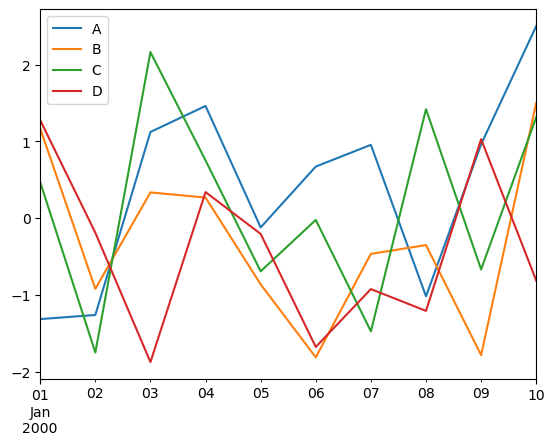

In [77]:
df = pd.DataFrame(np.random.randn(10,4),
        index=pd.date_range('1/1/2000',
        periods=10), columns=list('ABCD'))

df.plot()

In [ ]:
df = pd.DataFrame(np.random.rand(10,4),
        columns=['a','b','c','d'])
df.plot.bar()

In [ ]:
# stacked bar
df.plot.bar(stacked=True)

In [ ]:
# horizontal stacked bar
df.plot.barh(stacked=True)

In [ ]:
df = pd.DataFrame({'a':np.random.randn(1000)+1
                   ,'b':np.random.randn(1000),'c':
np.random.randn(1000) - 1}, columns=['a', 'b', 'c'])
# histogram
df.plot.hist(bins=20)

In [ ]:
df = pd.DataFrame(np.random.rand(50, 4)
    , columns=['a', 'b', 'c', 'd'])
df.plot.scatter(x='c', y='b')
df.plot.box()

In [ ]:
df = pd.DataFrame(3 * np.random.rand(4)
    , index=['a', 'b', 'c', 'd'], columns=['x'])
df.plot.pie(subplots=True)

Time for some bioinformatics exercises!

# Conclusion
You now have tools to do a LOT of manipulations of data frames with Pandas in Python. You are ready for a bioinformatics exercise.
1. **Completely solved** [Exploring ligand binding sites](./Submodule_2_PDB_Pandas_Exercise.ipynb) in a pdb file (protein structure file) using pandas and biopandas
2. **Guided exercise** with an [RNA seq dataset](./Submodule_2_Tutorial_2b_PandasGuidedExercise.ipynb)

If you do not want to practice at this point, the next tutorial picks up with how to [visualize your data](./Submodule_2_Tutorial3_VisualizingData.ipynb) with graphs in matplotlib


## Clean up
Remember to stop your Jupyter Notebook compute instance to avoid unnecessary charges..